First 5 Rows:
    Trip_Distance_km Time_of_Day Day_of_Week  Passenger_Count  \
0             19.35     Morning     Weekday              3.0   
1             47.59   Afternoon     Weekday              1.0   
2             36.87     Evening     Weekend              1.0   
3             30.33     Evening     Weekday              4.0   
4               NaN     Evening     Weekday              3.0   

  Traffic_Conditions Weather  Base_Fare  Per_Km_Rate  Per_Minute_Rate  \
0                Low   Clear       3.56         0.80             0.32   
1               High   Clear        NaN         0.62             0.43   
2               High   Clear       2.70         1.21             0.15   
3                Low     NaN       3.48         0.51             0.15   
4               High   Clear       2.93         0.63             0.32   

   Trip_Duration_Minutes  Trip_Price  
0                  53.82     36.2624  
1                  40.57         NaN  
2                  37.27     52.9032  
3    

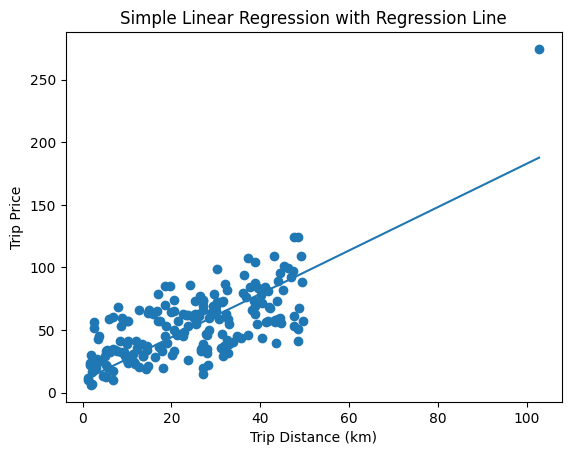

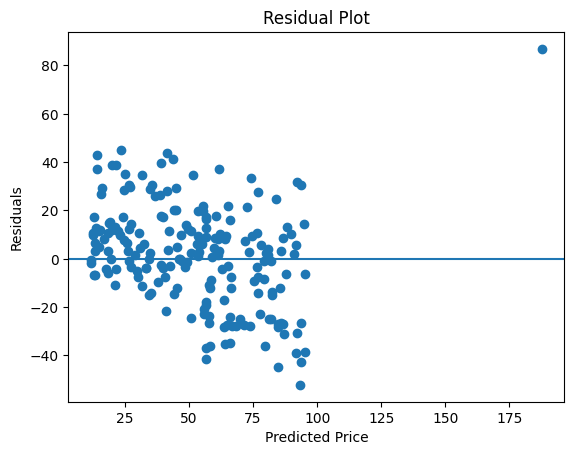

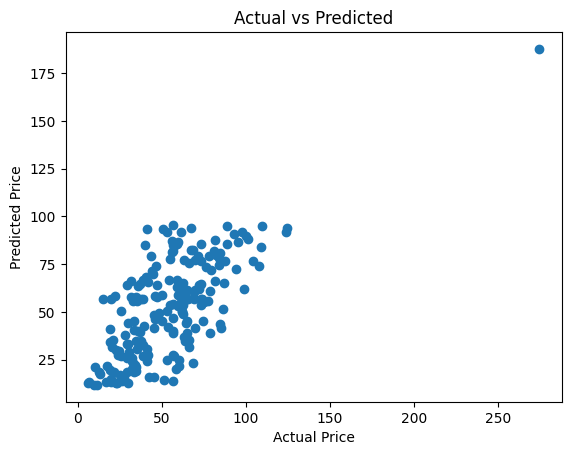

In [3]:
# ============================================
# 1. Import Libraries
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ============================================
# 2. Load Dataset
# ============================================
df = pd.read_csv("taxi_trip_pricing.csv")

print("First 5 Rows:\n", df.head())
print("\nMissing Values:\n", df.isnull().sum())

# ============================================
# 3. Data Cleaning (FIXED - no warning)
# ============================================

numeric_cols = [
    'Trip_Distance_km', 'Passenger_Count',
    'Base_Fare', 'Per_Km_Rate',
    'Per_Minute_Rate', 'Trip_Duration_Minutes',
    'Trip_Price'
]

categorical_cols = [
    'Time_of_Day', 'Day_of_Week',
    'Traffic_Conditions', 'Weather'
]

# Fill missing values (NO inplace warning)
df[numeric_cols] = df[numeric_cols].apply(lambda x: x.fillna(x.mean()))
df[categorical_cols] = df[categorical_cols].apply(lambda x: x.fillna(x.mode()[0]))

# Convert categorical → numeric
df = pd.get_dummies(df, drop_first=True)

# ============================================
# 4. Define Features & Target
# ============================================

X_simple = df[['Trip_Distance_km']]
y = df['Trip_Price']

X_multi = df.drop('Trip_Price', axis=1)

# ============================================
# 5. Train-Test Split
# ============================================

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# ============================================
# 6. Simple Linear Regression
# ============================================

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_simple = model_simple.predict(X_test_s)

mse_simple = mean_squared_error(y_test_s, y_pred_simple)
r2_simple = r2_score(y_test_s, y_pred_simple)

# ============================================
# 7. Multiple Linear Regression
# ============================================

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

y_pred_multi = model_multi.predict(X_test_m)

mse_multi = mean_squared_error(y_test_m, y_pred_multi)
r2_multi = r2_score(y_test_m, y_pred_multi)

# ============================================
# 8. Outputs
# ============================================

print("\n===== SIMPLE LINEAR REGRESSION =====")
print("Coefficient:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)
print("MSE:", mse_simple)
print("R2 Score:", r2_simple)

print("\n===== MULTIPLE LINEAR REGRESSION =====")
print("Intercept:", model_multi.intercept_)
print("MSE:", mse_multi)
print("R2 Score:", r2_multi)

print("\n===== COMPARISON =====")
print("Simple MSE:", mse_simple)
print("Multiple MSE:", mse_multi)

print("\nModel Accuracy (Multiple):", r2_multi * 100, "%")

# ============================================
# 9. Regression Line Plot
# ============================================

sorted_idx = X_test_s['Trip_Distance_km'].argsort()
X_sorted = X_test_s.iloc[sorted_idx]
y_sorted_pred = y_pred_simple[sorted_idx]

plt.scatter(X_test_s, y_test_s)
plt.plot(X_sorted, y_sorted_pred)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Price")
plt.title("Simple Linear Regression with Regression Line")
plt.show()

# ============================================
# 10. Residual Plot
# ============================================

residuals = y_test_s - y_pred_simple

plt.scatter(y_pred_simple, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ============================================
# 11. Actual vs Predicted Plot
# ============================================

plt.scatter(y_test_s, y_pred_simple)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()